# ARIMA Model

ARIMA is trained on the cleaned univariate CPU time series. The default order is intentionally modest for speed.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT / "src"))

from forecast_utils import *
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.arima.model import ARIMA

df = pd.read_csv(DATA_DIR / 'arima_data.csv', parse_dates=['timestamp'])
train, test = train_test_split_time(df)
print(train.shape, test.shape)

(7142, 2) (1786, 2)


In [2]:
ORDER = (5, 1, 0)
model = ARIMA(train['cpu_utilization'], order=ORDER)
fit = model.fit()
print(fit.summary())

                               SARIMAX Results                                
Dep. Variable:        cpu_utilization   No. Observations:                 7142
Model:                 ARIMA(5, 1, 0)   Log Likelihood               20057.227
Date:                Sun, 23 Aug 2026   AIC                         -40102.453
Time:                        18:21:06   BIC                         -40061.212
Sample:                             0   HQIC                        -40088.256
                               - 7142                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3157      0.001   -264.594      0.000      -0.318      -0.313
ar.L2         -0.3237      0.003    -97.743      0.000      -0.330      -0.317
ar.L3         -0.2672      0.003    -78.742      0.0

In [3]:
pred = fit.forecast(steps=len(test))
mse = mean_squared_error(test['cpu_utilization'], pred)
metrics = {
    'MAE': mean_absolute_error(test['cpu_utilization'], pred),
    'MSE': mse,
    'RMSE': np.sqrt(mse),
    'R2': r2_score(test['cpu_utilization'], pred),
}
metrics

{'MAE': 0.006894036485455558,
 'MSE': 0.00019452737884313083,
 'RMSE': np.float64(0.01394730722552317),
 'R2': -0.26418721972951364}

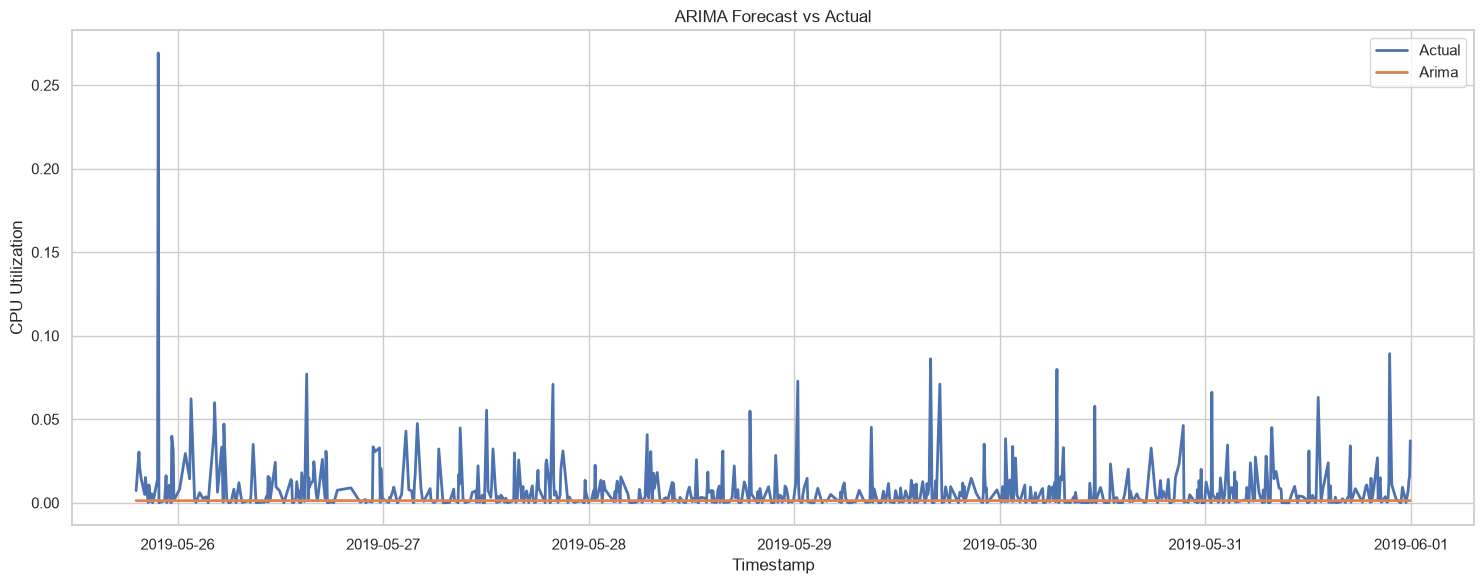

,timestamp,actual,arima
7142,2019-05-25 19:10:00,0.007260,0.001318
7143,2019-05-25 19:15:00,0.013036,0.001249
7144,2019-05-25 19:20:00,0.018813,0.001250
7145,2019-05-25 19:25:00,0.024589,0.001279
7146,2019-05-25 19:30:00,0.030365,0.001297


In [4]:
path, pred_df = save_prediction_csv('arima', test['timestamp'], test['cpu_utilization'], pred)
plot_actual_predicted(pred_df, 'arima', 'ARIMA Forecast vs Actual', 'arima_forecast.png')
pred_df.head()